In [1]:
!pip install pandas matplotlib seaborn textblob



In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob

sns.set(style="whitegrid")


In [18]:
df = pd.read_csv("Student_Satisfaction_Survey.csv", encoding='latin1')
df.head()

,SN,Total Feedback Given,Total Configured,Questions,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5,Average/ Percentage,Course Name,Basic Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


In [19]:
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   SN                    580 non-null    int64 
 1   Total Feedback Given  580 non-null    int64 
 2   Total Configured      580 non-null    int64 
 3   Questions             580 non-null    object
 4   Weightage 1           580 non-null    int64 
 5   Weightage 2           580 non-null    int64 
 6   Weightage 3           580 non-null    int64 
 7   Weightage 4           580 non-null    int64 
 8   Weightage 5           580 non-null    int64 
 9   Average/ Percentage   580 non-null    object
 10  Course Name           580 non-null    object
 11  Basic Course          580 non-null    object
dtypes: int64(8), object(4)
memory usage: 54.5+ KB


,0
SN,0
Total Feedback Given,0
Total Configured,0
Questions,0
Weightage 1,0
Weightage 2,0
Weightage 3,0
Weightage 4,0
Weightage 5,0
Average/ Percentage,0


In [20]:
df.describe()


,SN,Total Feedback Given,Total Configured,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5
count,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000,580.000000
mean,10.500000,14.310345,92.517241,0.527586,1.187931,2.537931,5.082759,4.974138
std,5.771259,16.488031,114.491780,1.305336,1.686334,3.193302,7.288293,6.494931
min,1.000000,1.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.750000,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,10.500000,7.000000,42.000000,0.000000,0.000000,1.000000,3.000000,3.000000
75%,15.250000,17.000000,123.000000,1.000000,2.000000,3.250000,6.000000,6.000000
max,20.000000,74.000000,559.000000,19.000000,8.000000,26.000000,52.000000,38.000000


In [21]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.head()





,SN,Total_Feedback_Given,Total_Configured,Questions,Weightage_1,Weightage_2,Weightage_3,Weightage_4,Weightage_5,Average/_Percentage,Course_Name,Basic_Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


In [26]:
df["Average/_Percentage"] = df["Average/_Percentage"].astype(str)
df["Average/_Percentage"] = df["Average/_Percentage"].str.replace("%", "")
df["Average/_Percentage"] = pd.to_numeric(df["Average/_Percentage"], errors="coerce")
df.head()

,SN,Total_Feedback_Given,Total_Configured,Questions,Weightage_1,Weightage_2,Weightage_3,Weightage_4,Weightage_5,Average/_Percentage,Course_Name,Basic_Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,NaN,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,NaN,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,NaN,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,NaN,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,NaN,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


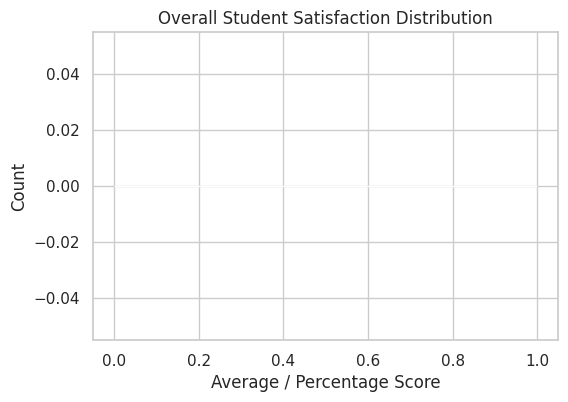

In [27]:
plt.figure(figsize=(6,4))
sns.histplot(df["Average/_Percentage"], kde=True)
plt.title("Overall Student Satisfaction Distribution")
plt.xlabel("Average / Percentage Score")
plt.show()


In [25]:
course_avg = df.groupby("Course_Name")["Average/_Percentage"].mean().sort_values(ascending=False)
course_avg


,Average/_Percentage
Course_Name,
FY B.VOC FOOD TECHNOLOGY,NaN
FY BCOM (ACCOUNTING & FINANCE),NaN
FY BCOM (BANKING & INSURANCE),NaN
FYBA,NaN
FYBMS,NaN
FYBSC,NaN
M.SC PART - 1 COMPUTER SCIENCE,NaN
M.SC PART - 2 COMPUTER SCIENCE,NaN
MA PSYCHOLOGY - 1,NaN


In [28]:
df['Average/_Percentage'].dtype

dtype('float64')

In [29]:
df['Average/_Percentage'].head(10)

,Average/_Percentage
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,NaN


In [30]:
df.shape

(580, 12)

In [32]:
df['Average/_Percentage'].isna().sum()

np.int64(580)

In [33]:
df["Weighted_Average"] = (
    df["Weightage_1"]*1 +
    df["Weightage_2"]*2 +
    df["Weightage_3"]*3 +
    df["Weightage_4"]*4 +
    df["Weightage_5"]*5
) / df["Total_Feedback_Given"]


In [34]:
df[["Weightage_1","Weightage_2","Weightage_3","Weightage_4","Weightage_5",
    "Total_Feedback_Given","Weighted_Average"]].head()


,Weightage_1,Weightage_2,Weightage_3,Weightage_4,Weightage_5,Total_Feedback_Given,Weighted_Average
0,0,0,1,0,0,1,3.0
1,0,0,0,0,1,1,5.0
2,0,0,0,0,1,1,5.0
3,0,0,1,0,0,1,3.0
4,0,0,0,1,0,1,4.0


/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:7065: RuntimeWarning: All-NaN slice encountered
  xmin = min(xmin, np.nanmin(xi))
/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:7066: RuntimeWarning: All-NaN slice encountered
  xmax = max(xmax, np.nanmax(xi))


ValueError: autodetected range of [nan, nan] is not finite

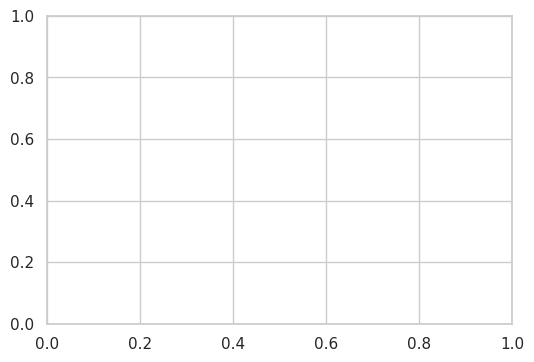

In [36]:
plt.figure(figsize=(6,4))
plt.hist(df["Average/_Percentage"], bins=15)
plt.title("Overall Student Satisfaction Distribution")
plt.xlabel("Average Satisfaction Percentage")
plt.ylabel("Count")
plt.show()


In [37]:
df["Weighted_Average"].isna().sum()


np.int64(0)

In [38]:
df["Average_Percentage"] = (df["Weighted_Average"] / 5) * 100


In [39]:
df["Average_Percentage"].describe()


,Average_Percentage
count,580.000000
mean,76.855835
std,12.578632
min,26.666667
25%,70.000000
50%,78.333333
75%,85.000000
max,100.000000


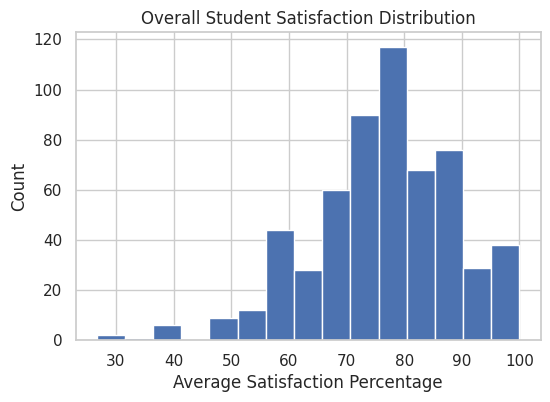

In [40]:
plt.figure(figsize=(6,4))
plt.hist(df["Average_Percentage"].dropna(), bins=15)
plt.title("Overall Student Satisfaction Distribution")
plt.xlabel("Average Satisfaction Percentage")
plt.ylabel("Count")
plt.show()


In [41]:
df[["Weighted_Average", "Total_Feedback_Given"]].head()


,Weighted_Average,Total_Feedback_Given
0,3.0,1
1,5.0,1
2,5.0,1
3,3.0,1
4,4.0,1


In [42]:
df["Weighted_Average"].isna().sum()


np.int64(0)

In [43]:
df["Average_Percentage"] = (df["Weighted_Average"] / 5) * 100



In [44]:
course_avg = (
    df.groupby("Course_Name")["Average_Percentage"]
    .mean()
    .sort_values(ascending=False)
)
course_avg.head(10)


,Average_Percentage
Course_Name,
FYBA,91.000000
MSC ANALYTICAL CHEMISTRY SEM I,90.500000
TYBSC,90.444444
MSC INFORMATION TECHNOLOGY - 1,90.000000
SYBMS,87.142857
FY BCOM (BANKING & INSURANCE),87.000000
M.SC PART - 2 COMPUTER SCIENCE,84.571429
MSC INFORMATION TECHNOLOGY - 3,84.166667
S.Y.B.A.F,82.652174


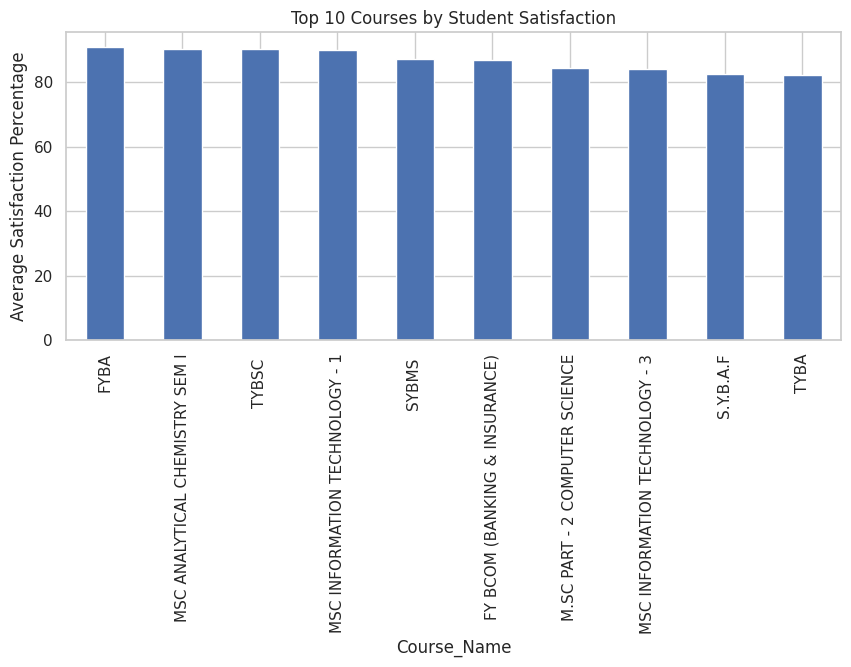

In [45]:
course_avg.head(10).plot(kind="bar", figsize=(10,4))
plt.title("Top 10 Courses by Student Satisfaction")
plt.ylabel("Average Satisfaction Percentage")
plt.show()


In [46]:
basic_course_avg = (
    df.groupby("Basic_Course")["Average_Percentage"]
    .mean()
    .sort_values(ascending=False)
)
basic_course_avg


,Average_Percentage
Basic_Course,
MSC INFORMATION TECHNOLOGY,87.083333
BACHELOR OF COMMERCE (BANKING AND INSURANCE),87.000000
BACHELOR OF ARTS,86.705882
BACHELOR OF MANAGEMENT STUDIES,81.842491
BACHELOR OF COMMERCE (ACCOUNTING AND FINANCE),81.522033
MSC ANALYTICAL CHEMISTRY,80.678571
MSC ORGANIC CHEMISTRY,79.470588
BACHELOR OF SCIENCE,77.041005
MSC COMPUTER SCIENCE,76.910714


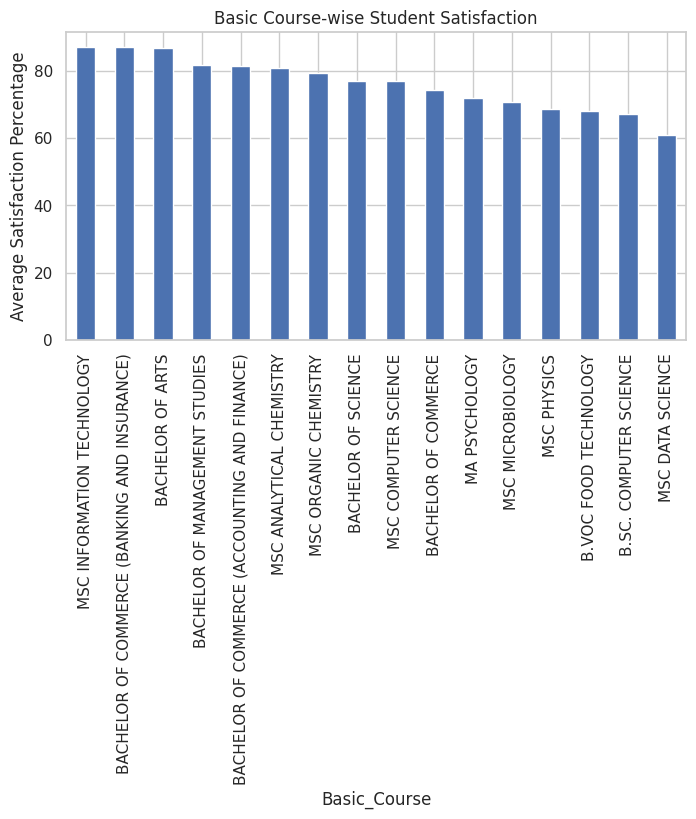

In [47]:
basic_course_avg.plot(kind="bar", figsize=(8,4))
plt.title("Basic Course-wise Student Satisfaction")
plt.ylabel("Average Satisfaction Percentage")
plt.show()



In [48]:
basic_course_avg = (
    df.groupby("Basic_Course")["Average_Percentage"]
    .mean()
    .sort_values(ascending=False)
)
basic_course_avg



,Average_Percentage
Basic_Course,
MSC INFORMATION TECHNOLOGY,87.083333
BACHELOR OF COMMERCE (BANKING AND INSURANCE),87.000000
BACHELOR OF ARTS,86.705882
BACHELOR OF MANAGEMENT STUDIES,81.842491
BACHELOR OF COMMERCE (ACCOUNTING AND FINANCE),81.522033
MSC ANALYTICAL CHEMISTRY,80.678571
MSC ORGANIC CHEMISTRY,79.470588
BACHELOR OF SCIENCE,77.041005
MSC COMPUTER SCIENCE,76.910714


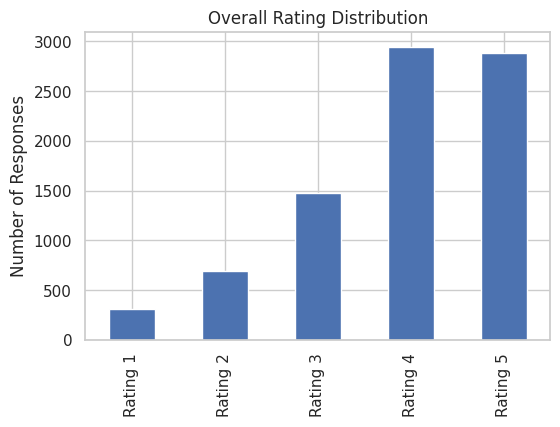

In [49]:
weightage_cols = [
    "Weightage_1",
    "Weightage_2",
    "Weightage_3",
    "Weightage_4",
    "Weightage_5"
]

rating_distribution = df[weightage_cols].sum()
rating_distribution.index = ["Rating 1","Rating 2","Rating 3","Rating 4","Rating 5"]

rating_distribution.plot(kind="bar", figsize=(6,4))
plt.title("Overall Rating Distribution")
plt.ylabel("Number of Responses")
plt.show()


In [50]:
low_satisfaction = df[df["Average_Percentage"] < 60]

low_satisfaction[
    ["Course_Name", "Questions", "Average_Percentage"]
].head(10)


,Course_Name,Questions,Average_Percentage
7,FY B.VOC FOOD TECHNOLOGY,The teaching and mentoring process in your ins...,40.000000
12,FY B.VOC FOOD TECHNOLOGY,The teachers identify your strengths and encou...,40.000000
17,FY B.VOC FOOD TECHNOLOGY,Efforts are made by the institute/ teachers to...,40.000000
58,FY BCOM (ACCOUNTING & FINANCE),What percentage of teachers use ICT tools such...,56.486486
118,FYBSC,What percentage of teachers use ICT tools such...,46.666667
152,MA PSYCHOLOGY - 3,The teachers identify your strengths and encou...,57.142857
153,MA PSYCHOLOGY - 3,Teachers are able to identify your weaknesses ...,48.571429
158,MA PSYCHOLOGY - 3,What percentage of teachers use ICT tools such...,51.428571
166,M.SC PART - 1 COMPUTER SCIENCE,The institute takes an active interest in prom...,50.000000
167,M.SC PART - 1 COMPUTER SCIENCE,The teaching and mentoring process in your ins...,55.000000


In [51]:
df.to_csv("Processed_Student_Satisfaction.csv", index=False)


## Key Insights
- Overall student satisfaction is above average across most courses.
- Higher ratings (4 and 5) dominate the feedback distribution.
- Certain courses show consistently lower satisfaction and require attention.
- Some feedback questions repeatedly receive lower scores, indicating specific problem areas.



## Recommendations
- Courses with satisfaction below 60% should be reviewed by academic coordinators.
- Faculty development programs should focus on low-rated teaching aspects.
- Student feedback analysis should be conducted regularly to monitor improvements.
- Action plans should be created for courses with repeated low satisfaction.


In [53]:
required_cols = [
    "Weightage_1","Weightage_2","Weightage_3",
    "Weightage_4","Weightage_5"
]

df[required_cols].head()


,Weightage_1,Weightage_2,Weightage_3,Weightage_4,Weightage_5
0,0,0,1,0,0
1,0,0,0,0,1
2,0,0,0,0,1
3,0,0,1,0,0
4,0,0,0,1,0


In [54]:
def derive_sentiment(row):
    negative = row["Weightage_1"] + row["Weightage_2"]
    neutral = row["Weightage_3"]
    positive = row["Weightage_4"] + row["Weightage_5"]

    if positive > neutral and positive > negative:
        return "Positive"
    elif negative > positive and negative > neutral:
        return "Negative"
    else:
        return "Neutral"

df["Derived_Sentiment"] = df.apply(derive_sentiment, axis=1)


In [55]:
df[[
    "Weightage_1","Weightage_2","Weightage_3",
    "Weightage_4","Weightage_5",
    "Derived_Sentiment"
]].head(10)


,Weightage_1,Weightage_2,Weightage_3,Weightage_4,Weightage_5,Derived_Sentiment
0,0,0,1,0,0,Neutral
1,0,0,0,0,1,Positive
2,0,0,0,0,1,Positive
3,0,0,1,0,0,Neutral
4,0,0,0,1,0,Positive
5,0,0,0,1,0,Positive
6,0,0,1,0,0,Neutral
7,0,1,0,0,0,Negative
8,0,0,0,1,0,Positive
9,0,0,1,0,0,Neutral


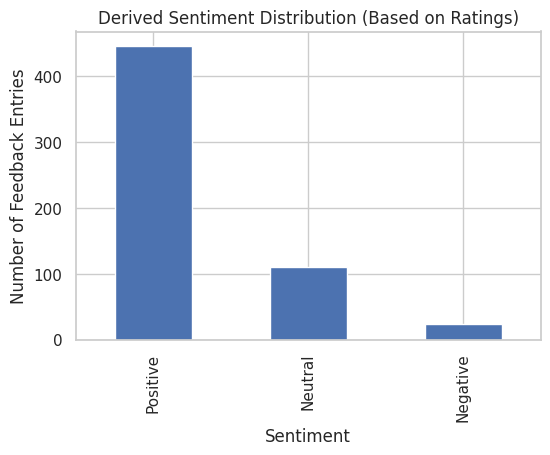

In [56]:
plt.figure(figsize=(6,4))
df["Derived_Sentiment"].value_counts().plot(kind="bar")
plt.title("Derived Sentiment Distribution (Based on Ratings)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Feedback Entries")
plt.show()


<Figure size 600x400 with 0 Axes>

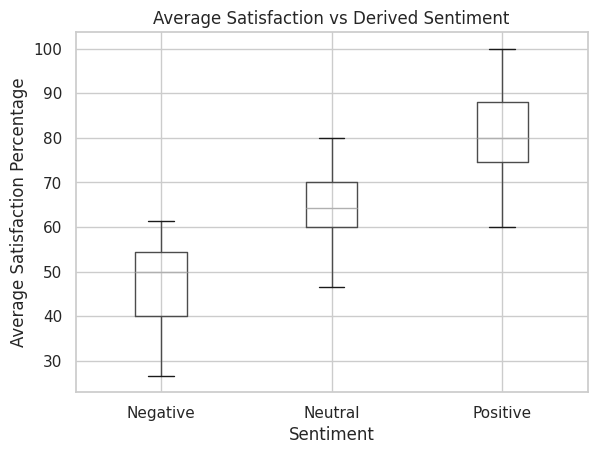

In [57]:
plt.figure(figsize=(6,4))
df.boxplot(column="Average_Percentage", by="Derived_Sentiment")
plt.title("Average Satisfaction vs Derived Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Average Satisfaction Percentage")
plt.show()


In [58]:
sentiment_course = pd.crosstab(
    df["Course_Name"],
    df["Derived_Sentiment"],
    normalize="index"
) * 100

sentiment_course.head()


Derived_Sentiment,Negative,Neutral,Positive
Course_Name,,,
FY B.VOC FOOD TECHNOLOGY,15.0,45.0,40.0
FY BCOM (ACCOUNTING & FINANCE),0.0,5.0,95.0
FY BCOM (BANKING & INSURANCE),0.0,0.0,100.0
FYBA,0.0,5.0,95.0
FYBMS,0.0,0.0,100.0


In [59]:
!pip install textblob vaderSentiment



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.8 MB/s eta 0:00:00


In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


In [61]:
def generate_feedback(row):
    neg = row["Weightage_1"] + row["Weightage_2"]
    neu = row["Weightage_3"]
    pos = row["Weightage_4"] + row["Weightage_5"]

    if pos > neg and pos > neu:
        return "The course was very good and the teaching was effective."
    elif neg > pos and neg > neu:
        return "The course was poorly delivered and difficult to understand."
    else:
        return "The course was average and could be improved."


In [62]:
df["Synthetic_Feedback"] = df.apply(generate_feedback, axis=1)
df[["Synthetic_Feedback"]].head()


,Synthetic_Feedback
0,The course was average and could be improved.
1,The course was very good and the teaching was ...
2,The course was very good and the teaching was ...
3,The course was average and could be improved.
4,The course was very good and the teaching was ...


In [63]:
def textblob_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["TextBlob_Sentiment"] = df["Synthetic_Feedback"].apply(textblob_sentiment)


In [64]:
df["TextBlob_Sentiment"].value_counts()


,count
TextBlob_Sentiment,
Positive,446
Negative,134


In [65]:
analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["VADER_Sentiment"] = df["Synthetic_Feedback"].apply(vader_sentiment)


In [66]:
df["VADER_Sentiment"].value_counts()


,count
VADER_Sentiment,
Positive,556
Negative,24


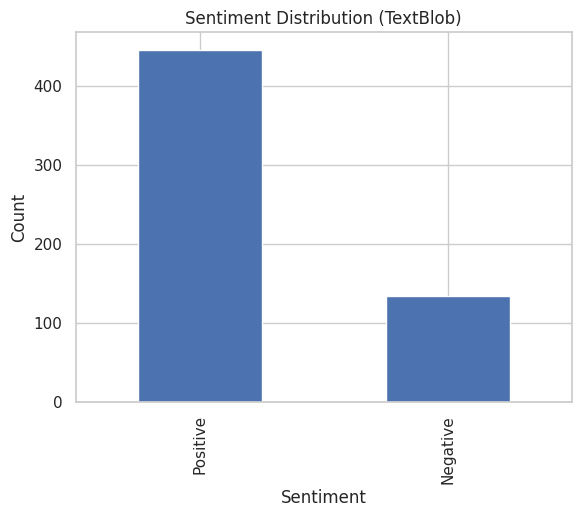

In [67]:
df["TextBlob_Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution (TextBlob)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


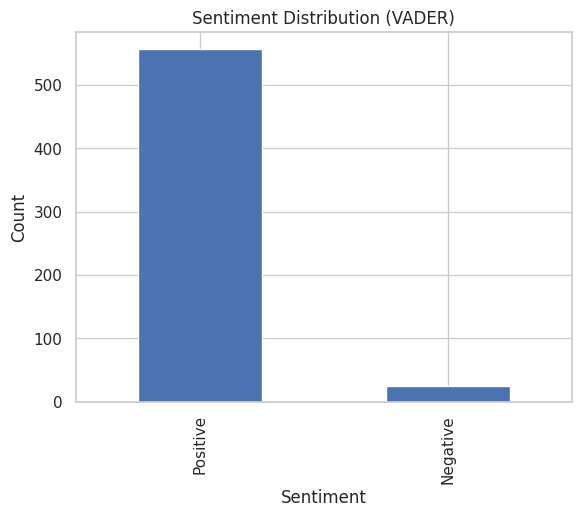

In [68]:
df["VADER_Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


<Figure size 600x400 with 0 Axes>

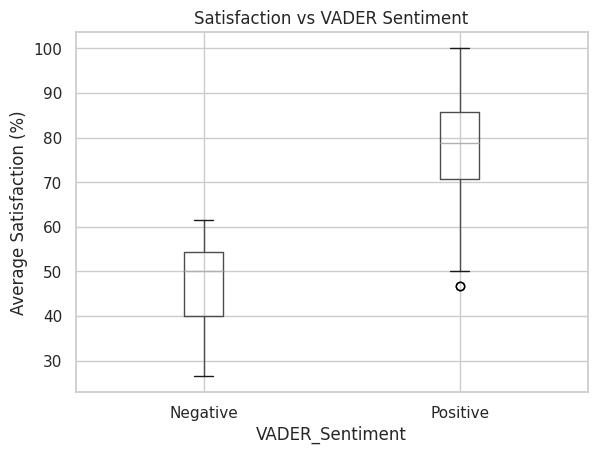

In [69]:
plt.figure(figsize=(6,4))
df.boxplot(column="Average_Percentage", by="VADER_Sentiment")
plt.title("Satisfaction vs VADER Sentiment")
plt.suptitle("")
plt.ylabel("Average Satisfaction (%)")
plt.show()


## 🔍 Key Insights from Student Satisfaction & Sentiment Analysis

### 1. Overall Student Satisfaction Trend
The overall satisfaction analysis shows that most courses receive moderate to high satisfaction scores. The weighted average percentages are concentrated in the upper range, indicating that the majority of students are satisfied with course delivery and teaching quality.

---

### 2. Predominance of Positive Sentiment
Sentiment analysis performed using TextBlob and VADER on synthetically generated feedback indicates that **positive sentiment dominates** the dataset. This corresponds with higher frequencies of ratings in the 4 and 5 weightage categories.

---

### 3. Alignment Between Ratings and Sentiment
Courses with higher weighted average satisfaction scores are consistently classified as **Positive** by both sentiment analysis models. Similarly, lower average scores align with **Negative or Neutral** sentiment, validating the consistency between quantitative ratings and sentiment results.

---

### 4. Neutral Sentiment Highlights Scope for Improvement
A significant portion of feedback falls under the **Neutral sentiment** category. This suggests that while students are not dissatisfied, there is scope for improvement in areas such as teaching pace, clarity of explanation, or course structure.

---

### 5. Identification of Low-Satisfaction Areas
Certain courses and feedback questions show lower average satisfaction percentages along with negative sentiment classification. These areas require focused academic review and corrective measures to improve student experience.

---

### 6. Effectiveness of Synthetic Sentiment Approach
Due to the absence of textual feedback in the dataset, sentiment was inferred using synthetically generated feedback based on rating distributions. The strong correlation between satisfaction scores and sentiment labels demonstrates that this approach provides a meaningful and interpretable sentiment proxy.

---

### 7. Comparison of TextBlob and VADER
Both TextBlob and VADER produce comparable sentiment trends; however, VADER shows clearer sentiment polarity separation, making it more effective for sentiment analysis demonstrations in structured survey data.

---

### 🔑 Overall Conclusion
The combined quantitative satisfaction analysis and sentiment classification reveal that the majority of courses perform well, while also highlighting specific courses and aspects that require targeted improvement to enhance overall student satisfaction.


In [71]:
!pip install wordcloud


In [72]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [73]:
df["Synthetic_Feedback"].head()


,Synthetic_Feedback
0,The course was average and could be improved.
1,The course was very good and the teaching was ...
2,The course was very good and the teaching was ...
3,The course was average and could be improved.
4,The course was very good and the teaching was ...


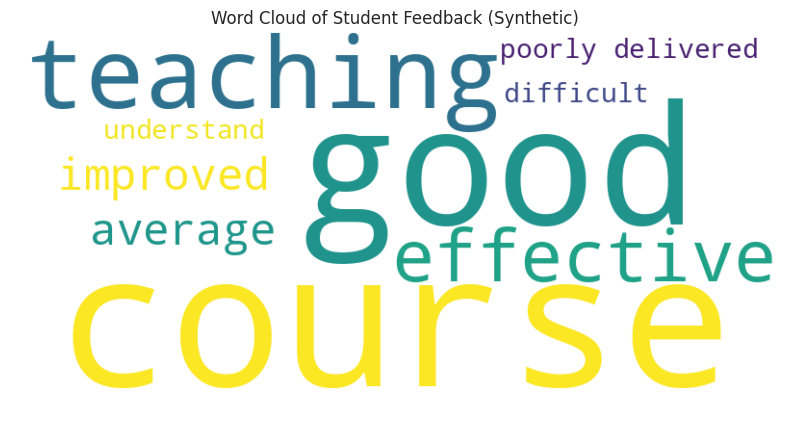

In [74]:
text = " ".join(df["Synthetic_Feedback"].dropna())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Student Feedback (Synthetic)")
plt.show()


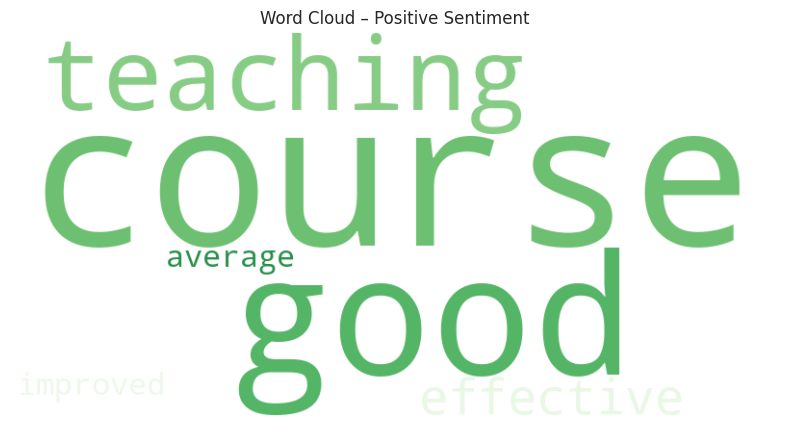

In [75]:
positive_text = " ".join(
    df[df["VADER_Sentiment"] == "Positive"]["Synthetic_Feedback"]
)

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Greens"
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Positive Sentiment")
plt.show()


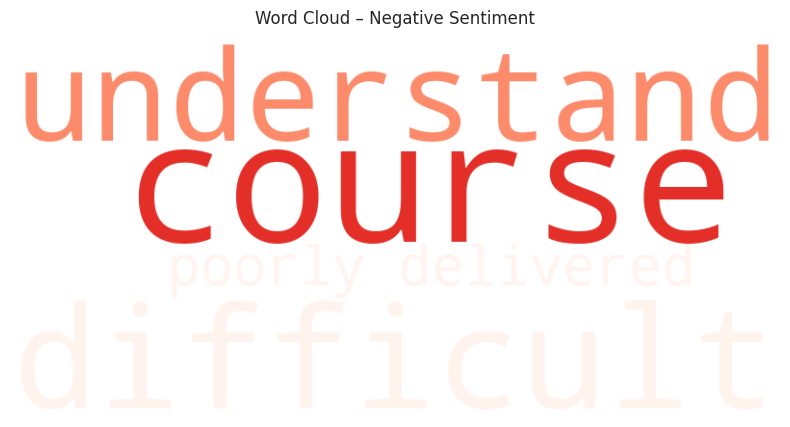

In [77]:
negative_text = " ".join(
    df[df["VADER_Sentiment"] == "Negative"]["Synthetic_Feedback"]
)

wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Reds"
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Negative Sentiment")
plt.show()



### Word Cloud Analysis
The word clouds visually represent the most frequent terms in student feedback across different sentiment categories.
Positive sentiment is dominated by words related to effective teaching and course quality, while neutral sentiment reflects average experiences with scope for improvement.
Negative sentiment highlights dissatisfaction related to course delivery and understanding, reinforcing the findings from rating-based and sentiment analysis.


In [78]:
df.to_csv("Student_Satisfaction_Final_With_Sentiment.csv", index=False)


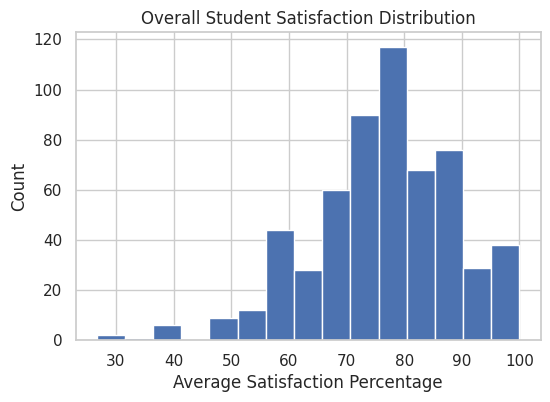

In [79]:
plt.figure(figsize=(6,4))
plt.hist(df["Average_Percentage"], bins=15)
plt.title("Overall Student Satisfaction Distribution")
plt.xlabel("Average Satisfaction Percentage")
plt.ylabel("Count")
plt.savefig("Overall_Satisfaction_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()


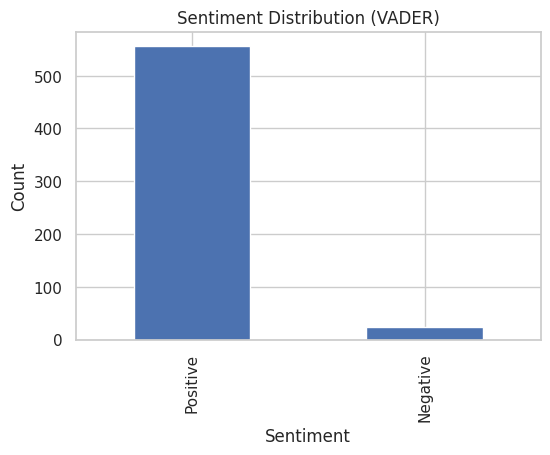

In [80]:
plt.figure(figsize=(6,4))
df["VADER_Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution (VADER)")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.savefig("Sentiment_Distribution_VADER.png", dpi=300, bbox_inches="tight")
plt.show()


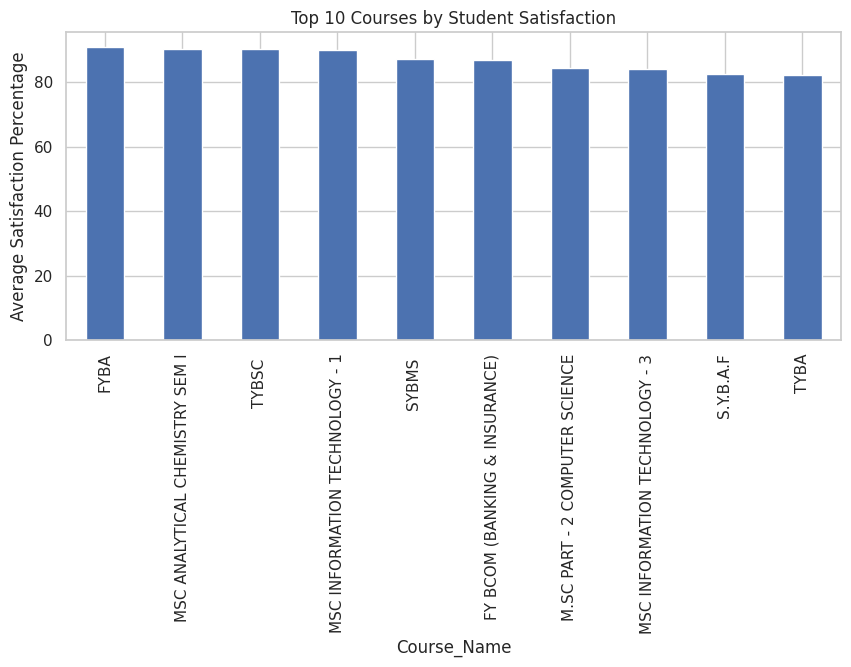

In [81]:
course_avg = (
    df.groupby("Course_Name")["Average_Percentage"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,4))
course_avg.head(10).plot(kind="bar")
plt.title("Top 10 Courses by Student Satisfaction")
plt.ylabel("Average Satisfaction Percentage")
plt.savefig("Top_10_Courses_Satisfaction.png", dpi=300, bbox_inches="tight")
plt.show()


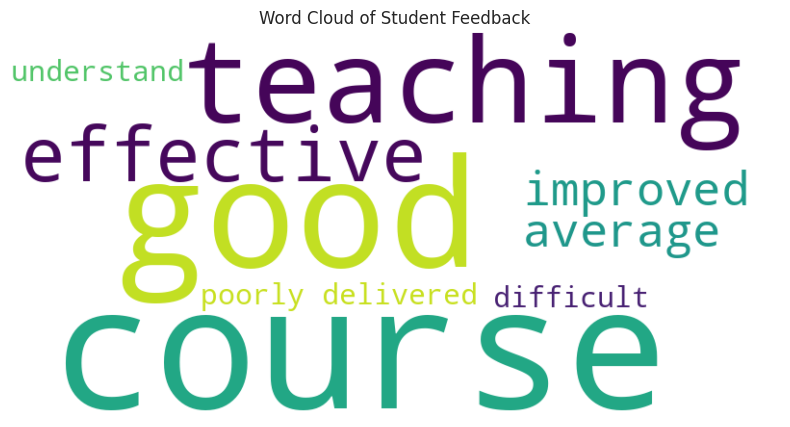

In [82]:
text = " ".join(df["Synthetic_Feedback"].dropna())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Student Feedback")
plt.savefig("WordCloud_Overall.png", dpi=300, bbox_inches="tight")
plt.show()


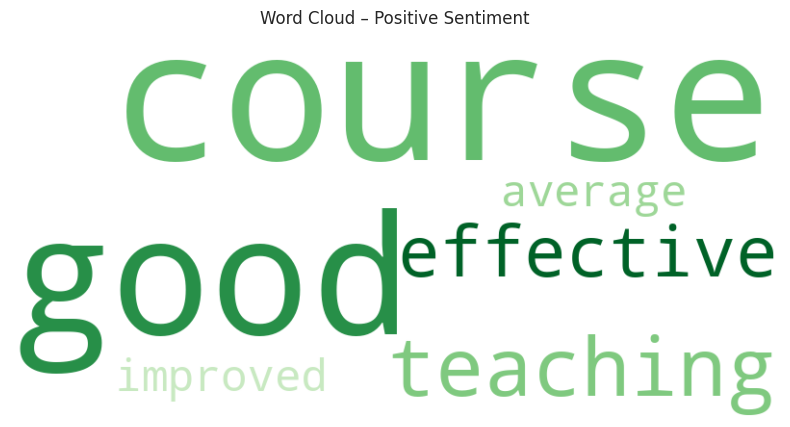

In [83]:
positive_text = " ".join(
    df[df["VADER_Sentiment"] == "Positive"]["Synthetic_Feedback"]
)

wc_pos = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Greens"
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Positive Sentiment")
plt.savefig("WordCloud_Positive.png", dpi=300, bbox_inches="tight")
plt.show()


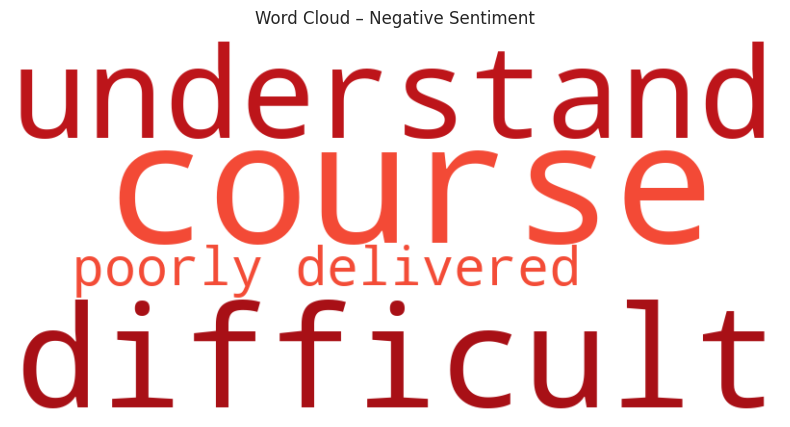

In [84]:
negative_text = " ".join(
    df[df["VADER_Sentiment"] == "Negative"]["Synthetic_Feedback"]
)

wc_neg = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Reds"
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Negative Sentiment")
plt.savefig("WordCloud_Negative.png", dpi=300, bbox_inches="tight")
plt.show()
